## Testing GitHub Palmistry Model

The GitHub palmistry model is tested on the same palm images used for the Roboflow API evaluation. The objective is to compare the visual accuracy of heart-line, head-line, and life-line detection.

In [ ]:
!git clone https://github.com/yeonsumia/palmistry.git

In [2]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("MediaPipe solutions available:", hasattr(mp, "solutions"))

MediaPipe version: 0.10.14
MediaPipe solutions available: True


In [3]:
image_files = (
    glob.glob("/kaggle/input/**/*.jpg", recursive=True) +
    glob.glob("/kaggle/input/**/*.jpeg", recursive=True) +
    glob.glob("/kaggle/input/**/*.png", recursive=True)
)

print("Total images:", len(image_files))

Total images: 11179


In [7]:
import os
import shutil

source_checkpoint = (
    "/kaggle/working/palmistry/code/checkpoint/"
    "checkpoint_aug_epoch70.pth"
)

destination_folder = (
    "/kaggle/working/palmistry/checkpoint"
)

destination_checkpoint = os.path.join(
    destination_folder,
    "checkpoint_aug_epoch70.pth"
)

os.makedirs(destination_folder, exist_ok=True)

shutil.copy(
    source_checkpoint,
    destination_checkpoint
)

print("Checkpoint copied to:")
print(destination_checkpoint)

print(
    "Checkpoint exists:",
    os.path.exists(destination_checkpoint)
)

Checkpoint copied to:
/kaggle/working/palmistry/checkpoint/checkpoint_aug_epoch70.pth
Checkpoint exists: True


In [9]:
classification_path = "/kaggle/working/palmistry/code/classification.py"

with open(classification_path, "r") as file:
    content = file.read()

old_code = (
    "skel_img = cv2.cvtColor("
    "skeletonize(palmline_img), "
    "cv2.COLOR_BGR2GRAY)"
)

new_code = """
skel_bool = skeletonize(palmline_img)
skel_uint8 = (skel_bool.astype("uint8") * 255)

if skel_uint8.ndim == 3:
    skel_img = cv2.cvtColor(
        skel_uint8,
        cv2.COLOR_BGR2GRAY
    )
else:
    skel_img = skel_uint8
"""

if old_code in content:
    content = content.replace(old_code, new_code)

    with open(classification_path, "w") as file:
        file.write(content)

    print("Correct skeleton fix applied.")
else:
    print("Exact old line not found.")

Correct skeleton fix applied.


In [10]:
with open(classification_path, "r") as file:
    updated_content = file.read()

print(
    "Old problematic code still exists:",
    "cv2.cvtColor(skeletonize(palmline_img)" in updated_content
)

Old problematic code still exists: False


In [13]:
!cd /kaggle/working/palmistry && git checkout -- code/classification.py

In [15]:
!python -m py_compile /kaggle/working/palmistry/code/classification.py

In [16]:
process = subprocess.run(
    [
        "python",
        "/kaggle/working/palmistry/code/read_palm.py",
        "--input",
        test_filename
    ],
    cwd="/kaggle/working/palmistry",
    capture_output=True,
    text=True
)

print("Return code:", process.returncode)
print("\nOutput:")
print(process.stdout)
print("\nError:")
print(process.stderr)

Return code: 0

Output:


Error:
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784990173.004368     433 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784990173.030320     433 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
W0000 00:00:1784990174.177669     439 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784990174.205536     439 inference_fee

In [17]:
import os

result_folder = "/kaggle/working/palmistry/results"

print("Result folder exists:", os.path.exists(result_folder))

if os.path.exists(result_folder):
    print("Files:")
    for file in os.listdir(result_folder):
        print(file)

Result folder exists: True
Files:
out_1-3.jpg
out_1-1.jpg
palm_without_background.jpg
out_1-2.jpg
warped_palm_clean.jpg
warped_palm.jpg
palm_lines.png
warped_1-2.jpg
result.jpg
warped_palm_mini.jpg
warped_palm_clean_mini.jpg


Total images found: 11179


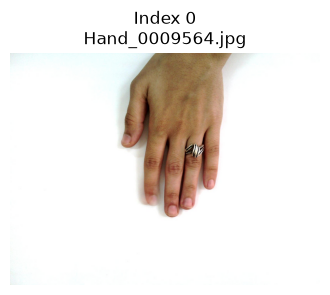

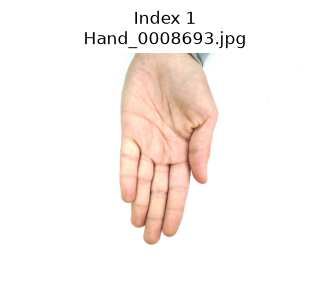

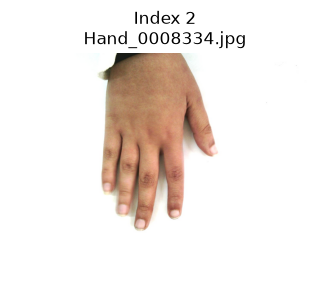

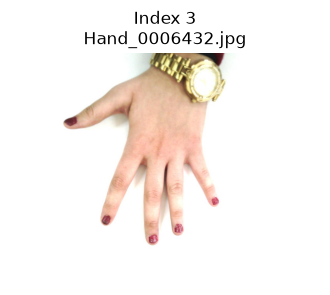

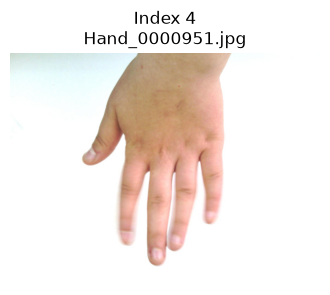

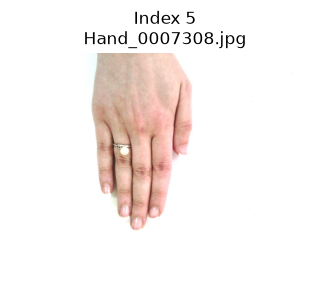

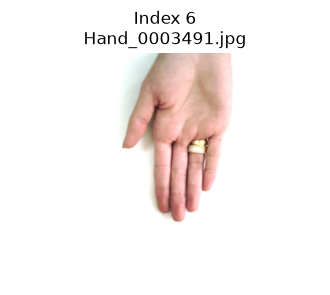

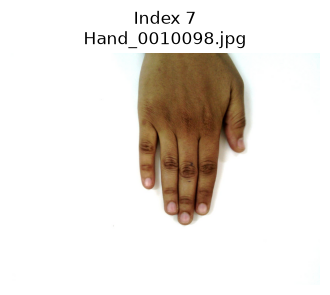

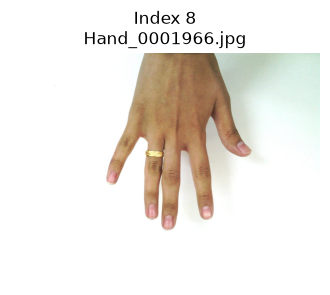

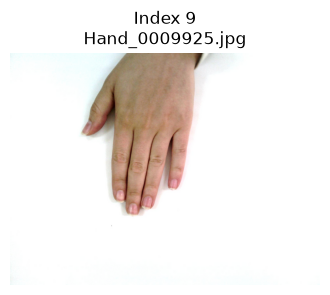

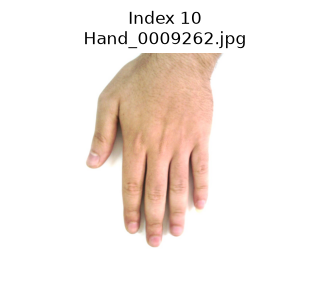

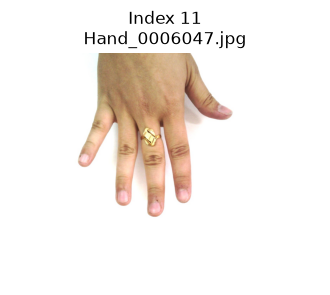

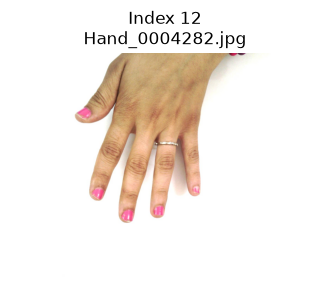

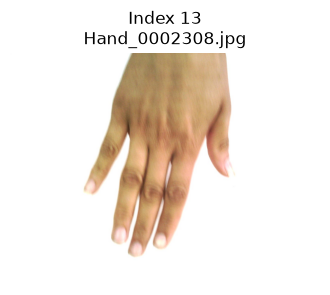

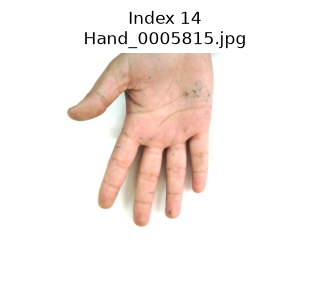

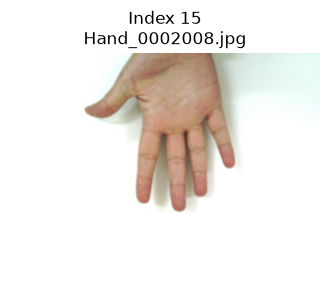

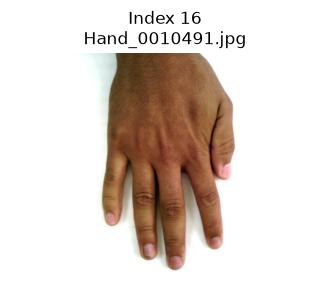

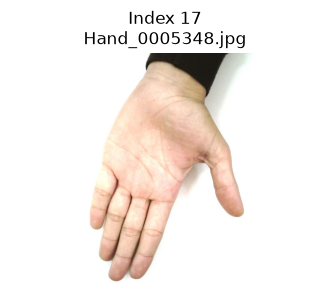

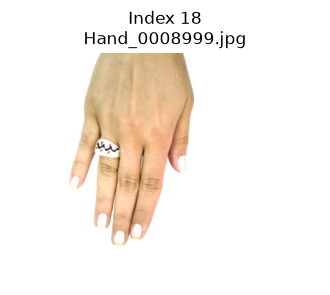

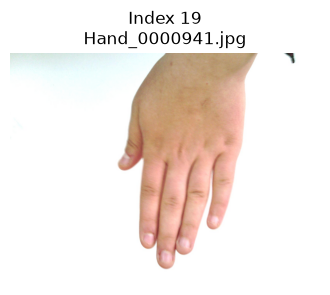

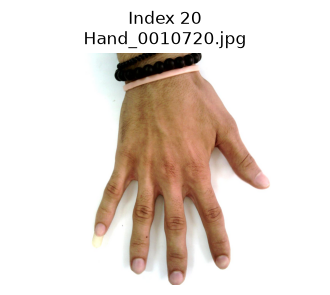

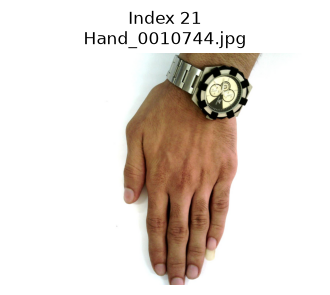

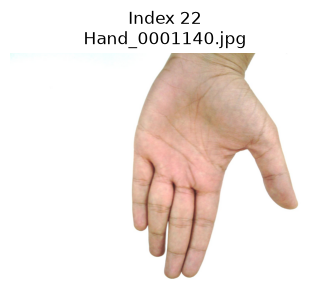

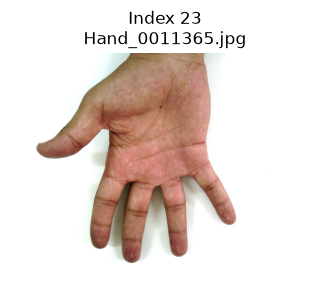

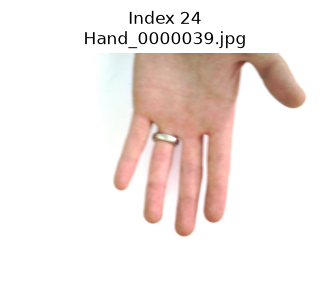

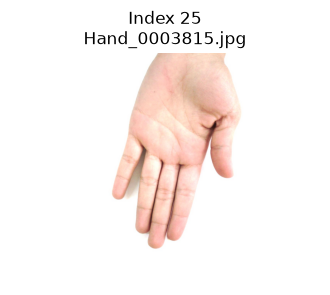

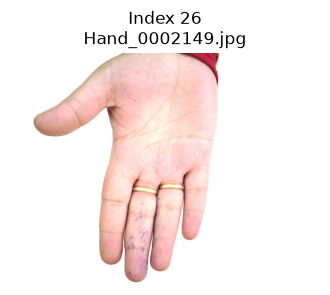

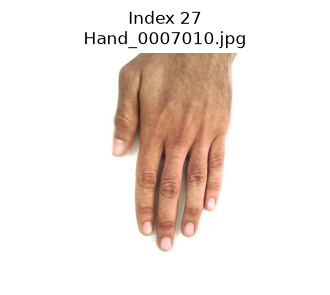

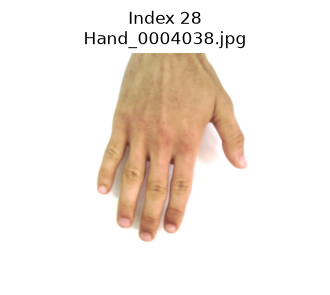

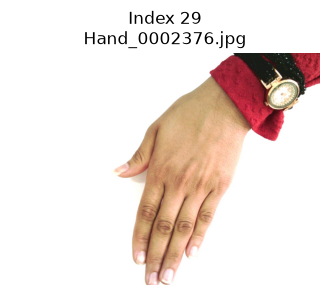

In [19]:
import glob
import matplotlib.pyplot as plt
from PIL import Image
import os

image_files = (
    glob.glob("/kaggle/input/**/*.jpg", recursive=True) +
    glob.glob("/kaggle/input/**/*.jpeg", recursive=True) +
    glob.glob("/kaggle/input/**/*.png", recursive=True)
)

print("Total images found:", len(image_files))

for index, image_path in enumerate(image_files[:30]):
    image = Image.open(image_path)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Index {index}\n{os.path.basename(image_path)}")
    plt.axis("off")
    plt.show()

In [20]:
selected_index = 14

source_image = image_files[selected_index]

print("Selected image:")
print(source_image)

Selected image:
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0005815.jpg


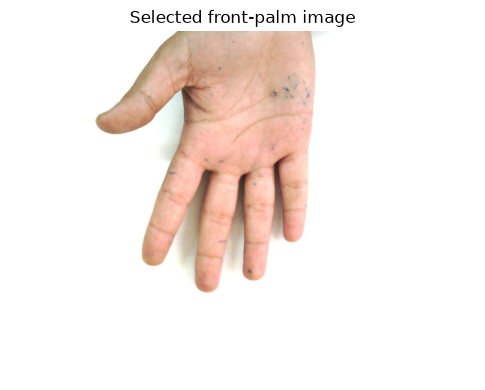

In [21]:
image = Image.open(source_image)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Selected front-palm image")
plt.axis("off")
plt.show()

In [22]:
import shutil
import os

repo_path = "/kaggle/working/palmistry"
input_folder = os.path.join(repo_path, "input")

os.makedirs(input_folder, exist_ok=True)

test_filename = "new_front_palm.jpg"

destination = os.path.join(
    input_folder,
    test_filename
)

shutil.copy(source_image, destination)

print("New image copied to:")
print(destination)

New image copied to:
/kaggle/working/palmistry/input/new_front_palm.jpg


In [23]:
import subprocess

process = subprocess.run(
    [
        "python",
        "/kaggle/working/palmistry/code/read_palm.py",
        "--input",
        test_filename
    ],
    cwd=repo_path,
    capture_output=True,
    text=True
)

print("Return code:", process.returncode)
print("\nOutput:")
print(process.stdout)
print("\nWarnings or errors:")
print(process.stderr)

Return code: 0

Output:


Warnings or errors:
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784990481.946958     474 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784990481.984735     474 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
W0000 00:00:1784990483.113941     479 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784990483.138887     477 

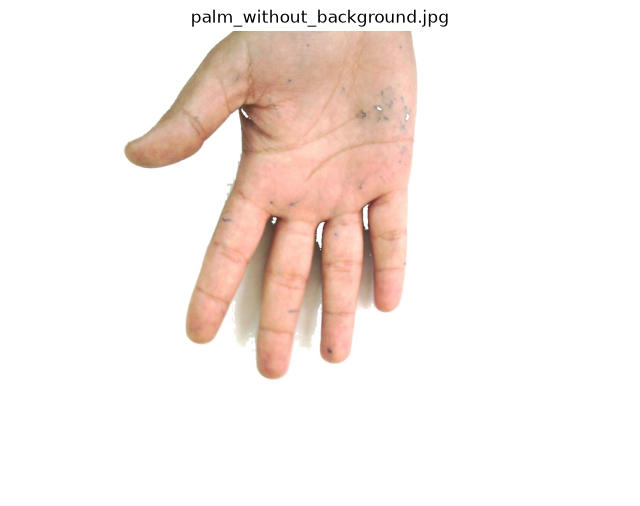

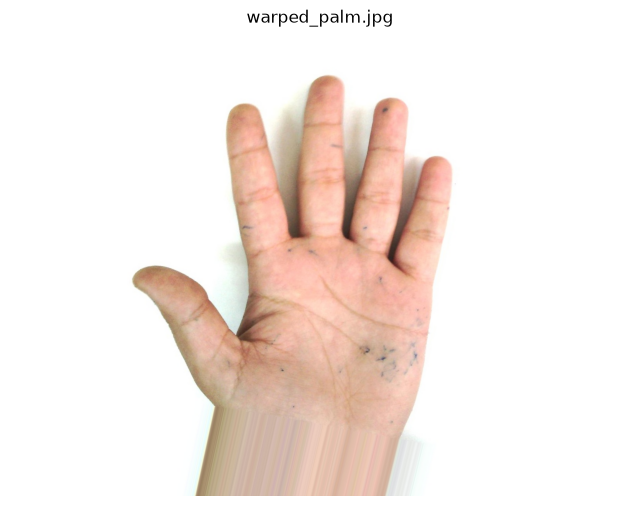

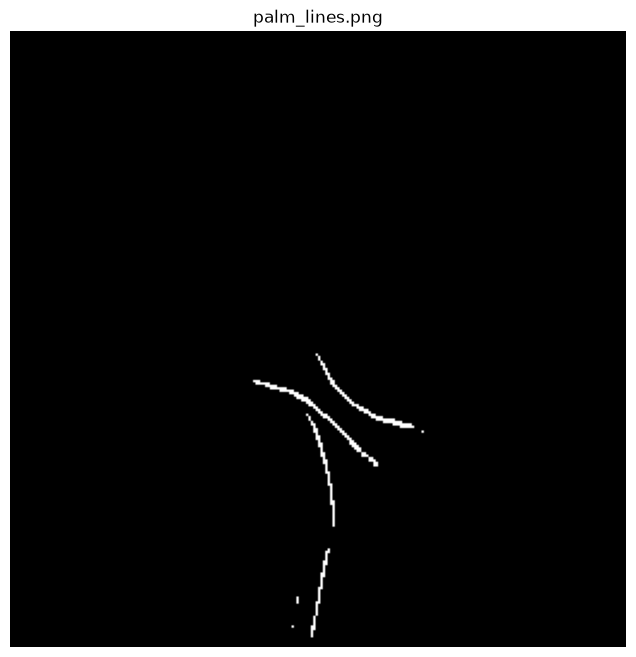

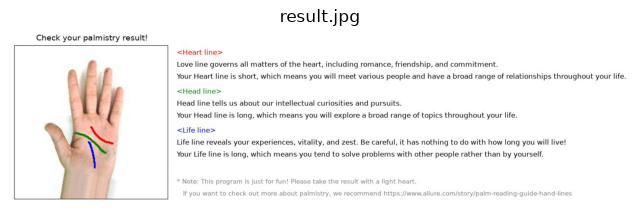

In [24]:
result_folder = "/kaggle/working/palmistry/results"

important_files = [
    "palm_without_background.jpg",
    "warped_palm.jpg",
    "palm_lines.png",
    "result.jpg"
]

for filename in important_files:
    path = os.path.join(result_folder, filename)

    if os.path.exists(path):
        image = Image.open(path)

        plt.figure(figsize=(8, 8))
        plt.imshow(image)
        plt.title(filename)
        plt.axis("off")
        plt.show()

In [25]:
palm_result = {
    "model": "GitHub Palmistry Model",
    "heart_line": {
        "status": "detected",
        "classification": "short"
    },
    "head_line": {
        "status": "detected",
        "classification": "long"
    },
    "life_line": {
        "status": "detected",
        "classification": "long"
    }
}

print(palm_result)

{'model': 'GitHub Palmistry Model', 'heart_line': {'status': 'detected', 'classification': 'short'}, 'head_line': {'status': 'detected', 'classification': 'long'}, 'life_line': {'status': 'detected', 'classification': 'long'}}


In [26]:
def create_palm_prompt(palm_result):
    prompt = f"""
You are a conversational palmistry assistant.

Use only the following model output:

Heart line: {palm_result['heart_line']['classification']}
Head line: {palm_result['head_line']['classification']}
Life line: {palm_result['life_line']['classification']}

Generate a natural conversational interpretation.

Requirements:
- Explain each detected line separately.
- Combine the three lines into one overall reflection.
- Do not make guaranteed predictions.
- Do not make medical claims.
- Present the reading as symbolic guidance and entertainment.
- End with one reflective question.
"""

    return prompt

palm_prompt = create_palm_prompt(palm_result)

print(palm_prompt)


You are a conversational palmistry assistant.

Use only the following model output:

Heart line: short
Head line: long
Life line: long

Generate a natural conversational interpretation.

Requirements:
- Explain each detected line separately.
- Combine the three lines into one overall reflection.
- Do not make guaranteed predictions.
- Do not make medical claims.
- Present the reading as symbolic guidance and entertainment.
- End with one reflective question.



## GitHub Palm Analysis Result

The GitHub palmistry model successfully processed a front-facing palm image.

The pipeline performed:

1. Background removal
2. Palm alignment and warping
3. Palm-line extraction
4. Heart, head, and life-line classification
5. Rule-based interpretation generation

For the tested image, the model classified the heart line as short, the head line as long, and the life line as long.

The final `result.jpg` was generated directly by the GitHub model. The interpretation is rule-based and not produced by an external LLM.

The structured palm output can now be connected to an external LLM to generate a more natural and conversational interpretation.

## Tarot User Interaction and External LLM Integration

### Objective

The objective of this task is to design an interactive tarot-reading workflow where the user can ask a question, select a tarot spread, draw virtual tarot cards, and receive a personalized conversational interpretation.

The base meanings of the tarot cards are retrieved from the tarot JSON dataset. After the card selection and initial interpretation, the structured output is sent to an external Large Language Model (LLM) to generate a natural and user-friendly response.


### Proposed Workflow

The planned tarot workflow is:

1. Ask the user to enter their name and question.
2. Allow the user to select a reading category.
3. Allow the user to choose a tarot spread.
4. Shuffle the virtual tarot deck.
5. Randomly select one or three tarot cards.
6. Randomly assign an upright or reversed orientation to each card.
7. Retrieve the corresponding meanings from the tarot JSON dataset.
8. Create a structured tarot interpretation.
9. Send the structured interpretation to an external LLM.
10. Generate a personalized conversational reading.
11. Allow the user to ask a follow-up question using the same selected cards.

### Supported Tarot Spreads

The initial prototype supports:

- **Single Card:** Provides general guidance related to the user's question.
- **Past–Present–Future:** Uses three cards to represent past influences, the present situation, and possible future guidance.

### Upright and Reversed Card Logic

The tarot dataset contains two categories of meanings:

- `meanings["light"]` is used for an upright card.
- `meanings["shadow"]` is used for a reversed card.

A reversed card is not automatically interpreted as completely negative. It may represent blockage, delay, caution, imbalance, internal influence, or an unresolved issue.

### System Architecture

The tarot module consists of three main components:

1. **Tarot JSON Dataset**
   - Contains 78 tarot cards.
   - Provides card names, keywords, light meanings, shadow meanings, fortune-telling statements, and reflection questions.

2. **Python Interaction Logic**
   - Accepts user input.
   - Selects the spread.
   - Shuffles and draws cards.
   - Assigns upright or reversed orientation.
   - Retrieves the appropriate dataset meanings.

3. **External LLM**
   - Receives the user's question and structured tarot result.
   - Relates the card meanings to the user's question.
   - Combines multiple cards into one coherent reading.
   - Produces a natural conversational response.
   - Supports follow-up questions using the same cards.

### Expected Output

The final output should include:

- User question and reading category
- Selected tarot spread
- Card names and spread positions
- Upright or reversed orientation
- Dataset-based meanings
- Personalized conversational interpretation
- Combined guidance
- A reflective question for the user

### Ethical Considerations

The generated tarot reading is intended for symbolic guidance, entertainment, and self-reflection. It should not make guaranteed predictions or provide medical, legal, or financial certainty.

In [27]:
import glob

tarot_json_files = glob.glob(
    "/kaggle/input/**/*.json",
    recursive=True
)

print("JSON files found:")

for index, path in enumerate(tarot_json_files):
    print(index, path)

JSON files found:
0 /kaggle/input/datasets/lsind18/tarot-json/tarot-images.json


In [28]:
import json

tarot_path = "/kaggle/input/datasets/lsind18/tarot-json/tarot-images.json"

with open(tarot_path, "r", encoding="utf-8") as file:
    tarot_data = json.load(file)

print("Data type:", type(tarot_data))

Data type: <class 'dict'>


In [29]:
if isinstance(tarot_data, dict):
    print("Top-level keys:")
    print(tarot_data.keys())

    for key, value in tarot_data.items():
        print("\nKey:", key)
        print("Value type:", type(value))

        if isinstance(value, list):
            print("Number of items:", len(value))

            if value:
                print("\nFirst item:")
                print(value[0])

elif isinstance(tarot_data, list):
    print("Number of items:", len(tarot_data))

    if tarot_data:
        print("\nFirst item:")
        print(tarot_data[0])

Top-level keys:
dict_keys(['description', 'cards'])

Key: description
Value type: <class 'str'>

Key: cards
Value type: <class 'list'>
Number of items: 78

First item:
{'name': 'The Fool', 'number': '0', 'arcana': 'Major Arcana', 'suit': 'Trump', 'img': 'm00.jpg', 'fortune_telling': ['Watch for new projects and new beginnings', 'Prepare to take something on faith', 'Something new comes your way; go for it'], 'keywords': ['freedom', 'faith', 'inexperience', 'innocence'], 'meanings': {'light': ['Freeing yourself from limitation', 'Expressing joy and youthful vigor', 'Being open-minded', 'Taking a leap of faith', 'Attuning yourself to your instincts', 'Being eager or curious', 'Exploring your potential', 'Embracing innovation and change'], 'shadow': ['Being gullible and naive', 'Taking unnecessary risks', 'Failing to be serious when required', 'Being silly or distracted', 'Lacking experience', 'Failing to honor well-established traditions and limits', 'Behaving inappropriately']}, 'Archet

In [30]:
from pprint import pprint

if isinstance(tarot_data, dict):
    for key, value in tarot_data.items():
        if isinstance(value, list) and value:
            print("Possible card-list key:", key)
            pprint(value[0])
            break
else:
    pprint(tarot_data[0])

Possible card-list key: cards
{'Archetype': 'The Divine Madman',
 'Elemental': 'Air',
 'Hebrew Alphabet': 'Aleph/Ox/1',
 'Mythical/Spiritual': 'Adam before the fall. Christ as a wandering holy '
                       'madman. Deity wrapped in human flesh. The Holy Spirit.',
 'Numerology': '0 (off the scale; pure potential)',
 'Questions to Ask': ['What would I do if I felt free to take a leap?',
                      'How willing am I to be vulnerable and open?',
                      'How might past experiences help in this new situation?'],
 'arcana': 'Major Arcana',
 'fortune_telling': ['Watch for new projects and new beginnings',
                     'Prepare to take something on faith',
                     'Something new comes your way; go for it'],
 'img': 'm00.jpg',
 'keywords': ['freedom', 'faith', 'inexperience', 'innocence'],
 'meanings': {'light': ['Freeing yourself from limitation',
                        'Expressing joy and youthful vigor',
                        'Bein

In [31]:
cards = tarot_data["cards"]

print("Total tarot cards:", len(cards))
print("First card:", cards[0]["name"])

Total tarot cards: 78
First card: The Fool


In [38]:
user_name = input("Enter your name: ").strip()

user_question = input(
    "What would you like guidance about? "
).strip()

print("\nChoose a reading category:")
print("1. Career")
print("2. Relationship")
print("3. Personal Growth")
print("4. General Guidance")

category_choice = input(
    "Enter your choice (1-4): "
).strip()

categories = {
    "1": "Career",
    "2": "Relationship",
    "3": "Personal Growth",
    "4": "General Guidance"
}

reading_category = categories.get(
    category_choice,
    "General Guidance"
)

print("Selected category:", reading_category)

Enter your name:  Ankita Pagare
What would you like guidance about?  About my study



Choose a reading category:
1. Career
2. Relationship
3. Personal Growth
4. General Guidance


Enter your choice (1-4):  1


Selected category: Career


In [39]:
print("\nChoose a tarot spread:")
print("1. Single Card")
print("2. Past-Present-Future")

spread_choice = input(
    "Enter your choice (1 or 2): "
).strip()

if spread_choice == "2":
    spread_name = "Past-Present-Future"
    positions = ["Past", "Present", "Future"]
else:
    spread_name = "Single Card"
    positions = ["Guidance"]

print("Selected spread:", spread_name)


Choose a tarot spread:
1. Single Card
2. Past-Present-Future


Enter your choice (1 or 2):  2


Selected spread: Past-Present-Future


In [40]:
import random

selected_cards = random.sample(
    cards,
    len(positions)
)

print("Cards selected:", len(selected_cards))

Cards selected: 3


In [41]:
reading_cards = []

for position, card in zip(positions, selected_cards):
    orientation = random.choice([
        "upright",
        "reversed"
    ])

    if orientation == "upright":
        meanings = card["meanings"]["light"]
    else:
        meanings = card["meanings"]["shadow"]

    reading_cards.append({
        "position": position,
        "name": card["name"],
        "number": card["number"],
        "arcana": card["arcana"],
        "suit": card["suit"],
        "orientation": orientation,
        "keywords": card["keywords"],
        "meanings": meanings,
        "fortune_telling": card["fortune_telling"],
        "reflection_questions": card["Questions to Ask"],
        "image": card["img"]
    })

In [42]:
print("\n" + "=" * 60)
print("TAROT READING")
print("=" * 60)

print("Name:", user_name)
print("Question:", user_question)
print("Category:", reading_category)
print("Spread:", spread_name)

for card in reading_cards:
    print("\n" + "-" * 50)
    print("Position:", card["position"])
    print("Card:", card["name"])
    print("Orientation:", card["orientation"])
    print("Keywords:", ", ".join(card["keywords"]))

    print("\nDataset meanings:")
    for meaning in card["meanings"][:4]:
        print("-", meaning)


TAROT READING
Name: Ankita Pagare
Question: About my study
Category: Career
Spread: Past-Present-Future

--------------------------------------------------
Position: Past
Card: The Empress
Orientation: upright
Keywords: fertility, productivity, ripeness, nurturing

Dataset meanings:
- Nurturing yourself and others
- Bearing fruit
- Celebrating your body
- Bearing (literal or figurative) children

--------------------------------------------------
Position: Present
Card: Judgement
Orientation: upright
Keywords: revival, renewal, resurrection, evaluation, invitation

Dataset meanings:
- Receiving a wake-up call
- Discovering a new purpose in life
- Becoming totally and completely yourself
- Receiving a well-deserved reward

--------------------------------------------------
Position: Future
Card: Seven of Wands
Orientation: reversed
Keywords: bravery, resolve, determination

Dataset meanings:
- Having a chip on your shoulder
- Taking unnecessary risks as a means of proving your fearless

In [44]:
tarot_result = {
    "user_name": user_name,
    "user_question": user_question,
    "reading_category": reading_category,
    "spread": spread_name,
    "cards": reading_cards
}

In [45]:
import json

print(
    json.dumps(
        tarot_result,
        indent=2,
        ensure_ascii=False
    )
)

{
  "user_name": "Ankita Pagare",
  "user_question": "About my study",
  "reading_category": "Career",
  "spread": "Past-Present-Future",
  "cards": [
    {
      "position": "Past",
      "name": "The Empress",
      "number": "3",
      "arcana": "Major Arcana",
      "suit": "Trump",
      "orientation": "upright",
      "keywords": [
        "fertility",
        "productivity",
        "ripeness",
        "nurturing"
      ],
      "meanings": [
        "Nurturing yourself and others",
        "Bearing fruit",
        "Celebrating your body",
        "Bearing (literal or figurative) children",
        "Reveling in luxury",
        "Mothering those around you in positive ways",
        "Enjoying your sexuality",
        "Getting things done"
      ],
      "fortune_telling": [
        "Pregnancy is in the cards",
        "An opportunity to be involved in luxurious sexuality is coming",
        "Beware a tendency toward addiction"
      ],
      "reflection_questions": [
        "Wha

In [46]:
def create_tarot_prompt(tarot_result):
    prompt = f"""
You are a conversational tarot-reading assistant.

Use only the supplied tarot dataset meanings as the main source for the reading.

User name: {tarot_result['user_name']}
User question: {tarot_result['user_question']}
Reading category: {tarot_result['reading_category']}
Spread: {tarot_result['spread']}

Selected cards:
"""

    for card in tarot_result["cards"]:
        prompt += f"""
Position: {card['position']}
Card: {card['name']}
Orientation: {card['orientation']}
Keywords: {", ".join(card['keywords'])}
Dataset meanings:
"""

        for meaning in card["meanings"]:
            prompt += f"- {meaning}\n"

    prompt += """
Instructions:
1. Speak directly and naturally to the user.
2. Explain every card according to its spread position.
3. Connect the card meanings to the user's question.
4. Combine all cards into one coherent interpretation.
5. Treat reversed cards as caution, blockage, imbalance, delay, or internal influence where appropriate.
6. Do not make guaranteed predictions.
7. Do not provide medical, legal, or financial certainty.
8. Present the reading as symbolic guidance and self-reflection.
9. End with one practical reflection question.
"""

    return prompt

In [47]:
llm_prompt = create_tarot_prompt(
    tarot_result
)

print(llm_prompt)


You are a conversational tarot-reading assistant.

Use only the supplied tarot dataset meanings as the main source for the reading.

User name: Ankita Pagare
User question: About my study
Reading category: Career
Spread: Past-Present-Future

Selected cards:

Position: Past
Card: The Empress
Orientation: upright
Keywords: fertility, productivity, ripeness, nurturing
Dataset meanings:
- Nurturing yourself and others
- Bearing fruit
- Celebrating your body
- Bearing (literal or figurative) children
- Reveling in luxury
- Mothering those around you in positive ways
- Enjoying your sexuality
- Getting things done

Position: Present
Card: Judgement
Orientation: upright
Keywords: revival, renewal, resurrection, evaluation, invitation
Dataset meanings:
- Receiving a wake-up call
- Discovering a new purpose in life
- Becoming totally and completely yourself
- Receiving a well-deserved reward
- Passing an evaluation or examination
- Welcoming the start of a new phase of life

Position: Future
C

In [48]:
!pip install -q google-genai

In [49]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

gemini_api_key = user_secrets.get_secret(
    "GEMINI_API_KEY"
)

print("Gemini API key loaded successfully.")

Gemini API key loaded successfully.


In [50]:
from google import genai

client = genai.Client(
    api_key=gemini_api_key
)

In [52]:
from google import genai
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
api_key = secrets.get_secret("GEMINI_API_KEY")

client = genai.Client(api_key=api_key)

print("Models available for generateContent:\n")

for model in client.models.list():
    actions = getattr(model, "supported_actions", []) or []

    if "generateContent" in actions:
        print(model.name)

Models available for generateContent:

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-flash
models/lyria-3-clip-preview
models/lyria

In [53]:
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-

In [54]:
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=llm_prompt
)

conversational_reading = response.text

print("\n" + "=" * 60)
print("CONVERSATIONAL TAROT READING")
print("=" * 60)
print(conversational_reading)


CONVERSATIONAL TAROT READING
Hello Ankita, welcome to your reading. Let's explore what the cards suggest regarding your studies through the perspective of your past, present, and potential future guidance.

### **Past: The Empress (Upright)**
In your past position, **The Empress** highlights a rich period of growth, productivity, and care in your educational background. You likely approached your studies by nurturing your abilities, taking care of your well-being, and focusing on "getting things done." This card indicates that your past efforts were fruitful, allowing you to build a strong, supportive foundation for your knowledge to grow.

### **Present: Judgement (Upright)**
Currently, **Judgement** signifies a pivotal moment of clarity, evaluation, and renewal in your academic life. You may be undergoing or passing an important evaluation or examination, or receiving a well-deserved reward for your dedication. This card suggests you are experiencing a wake-up call, discovering a cl

In [55]:
from google import genai
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
api_key = secrets.get_secret("GEMINI_API_KEY")

client = genai.Client(api_key=api_key)

preferred_models = [
    "gemini-3.6-flash",
    "gemini-3.5-flash",
    "gemini-3.5-flash-lite",
    "gemini-3.1-flash-lite"
]

available_models = []

for model in client.models.list():
    model_name = model.name.replace("models/", "")
    available_models.append(model_name)

selected_model = None

for preferred_model in preferred_models:
    if preferred_model in available_models:
        selected_model = preferred_model
        break

if selected_model is None:
    print("No preferred Flash model found.")
    print("Available models:")
    
    for model_name in available_models:
        print(model_name)
else:
    print("Using model:", selected_model)

    response = client.models.generate_content(
        model=selected_model,
        contents=llm_prompt
    )

    conversational_reading = response.text

    print("\n" + "=" * 60)
    print("CONVERSATIONAL TAROT READING")
    print("=" * 60)
    print(conversational_reading)

Using model: gemini-3.6-flash

CONVERSATIONAL TAROT READING
Hello Ankita, welcome to your tarot reading. Today we are looking into your studies using a Past-Present-Future spread to give you symbolic guidance and a fresh perspective on your academic journey.

Here is what the cards reveal for you:

### **Past: The Empress (Upright)**
In your past position, **The Empress** shows that your previous approach to your studies was marked by productivity and growth. You were able to focus on getting things done, nurturing your talents, and seeing your efforts bear fruit. This card suggests you established a strong, supportive foundation where your dedication allowed your knowledge and skills to expand naturally.

### **Present: Judgement (Upright)**
In your present position, **Judgement** indicates that you are currently at a major turning point or phase of evaluation in your studies. You may be passing an important examination, receiving a wake-up call about your academic direction, or disco

In [57]:
follow_up_question = input(
    "\nAsk a follow-up question about this reading, "
    "or press Enter to finish: "
).strip()


Ask a follow-up question about this reading, or press Enter to finish:  What should I focus on most in my studies right now?


In [58]:
if follow_up_question:
    follow_up_prompt = f"""
The user previously received this tarot reading:

{conversational_reading}

Original user question:
{tarot_result['user_question']}

Selected cards:
"""

    for card in tarot_result["cards"]:
        follow_up_prompt += f"""
Position: {card['position']}
Card: {card['name']}
Orientation: {card['orientation']}
Dataset meanings: {", ".join(card['meanings'])}
"""

    follow_up_prompt += f"""

User's follow-up question:
{follow_up_question}

Respond naturally and conversationally.

Rules:
- Use the same selected cards.
- Do not draw new cards.
- Connect the answer to the earlier reading.
- Do not make guaranteed predictions.
- Present the answer as symbolic guidance and self-reflection.
"""

    follow_up_response = client.models.generate_content(
        model=selected_model,
        contents=follow_up_prompt
    )

    print("\n" + "=" * 60)
    print("FOLLOW-UP TAROT RESPONSE")
    print("=" * 60)
    print(follow_up_response.text)

else:
    print("Tarot reading completed.")


FOLLOW-UP TAROT RESPONSE
Right now, Ankita, the center of your reading—**Judgement**—gives you the clearest indicator of where to direct your energy. 

Based on your cards, your primary focus right now should be on **honest self-assessment and aligning with your true academic purpose.** 

Here is how you can focus that energy using the story your cards tell:

### 1. **Focus on Self-Evaluation & Clear Purpose (Judgement)**
Because you are in a "Judgement" phase, now is the time to step back and take stock of your studies. Ask yourself: *Are my current study habits, subjects, and routines truly serving my long-term goals?* Focus on evaluating what is working and what isn’t, without judging yourself harshly. It’s about recognizing where you are right now so you can make conscious, meaningful choices about where you want to go next.

### 2. **Focus on Receptivity Instead of Defensiveness (Seven of Wands Reversed)**
To prepare for the road ahead, make it a daily habit to practice **opennes

## Tarot Interaction and External LLM Integration

An interactive tarot-reading workflow was successfully implemented.

The user can:

1. Enter their name and question
2. Select a reading category
3. Choose a single-card or Past-Present-Future spread
4. Receive randomly selected tarot cards
5. Receive upright or reversed orientations
6. Retrieve corresponding meanings from the tarot JSON dataset
7. Send the structured tarot result to the Gemini external LLM
8. Receive a natural and conversational interpretation
9. Ask a follow-up question using the same selected cards

The tarot dataset acts as the source of card meanings, while Gemini converts the structured result into a personalized conversational reading.

## Example Test

**User name:** Ankita  
**Question:** Guidance regarding studies  
**Category:** Personal Growth  
**Spread:** Past-Present-Future  

**Selected cards:**

- Past: The Empress, Upright
- Present: Judgement, Upright
- Future: Seven of Wands, Reversed

The structured card meanings were sent to the Gemini external LLM. Gemini generated a conversational interpretation connected to the user's study-related question and ended with a reflective question.

## Limitations

- Tarot cards are selected randomly and are not predicted by a machine-learning model.
- The tarot JSON dataset provides the base meanings.
- The external LLM converts the structured meanings into conversational text.
- The quality of the final reading depends on the prompt and the selected card meanings.
- The reading is intended for symbolic guidance and self-reflection, not guaranteed prediction.
- Internet access and a valid Gemini API key are required for external LLM generation.

In [ ]:
## Technical Architecture

The tarot module consists of three main components:

1. **Tarot Dataset**
   - Contains 78 tarot cards
   - Includes keywords, light meanings, shadow meanings, and reflection questions

2. **Python Interaction Logic**
   - Accepts the user's question
   - Allows spread selection
   - Randomly selects cards
   - Assigns upright or reversed orientation
   - Retrieves the corresponding dataset meanings

3. **External LLM Integration**
   - Receives the structured tarot output
   - Generates a personalized conversational interpretation
   - Supports follow-up questions using the same selected cards

## Final Status

The interaction between tarot cards and the user was successfully implemented. The interpreted tarot output was connected to the Gemini external LLM, which generated a natural conversational reading and supported a follow-up question.